In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import shap

In [113]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
train = pd.read_csv("Train.csv", index_col='id')
print(train.shape)
train.head(5)

(100000, 24)


,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
id,,,,,,,,,,,,,,,,,,,,,
0,2011-1,560,NaN,2,59,3,0,30.0,1.0,5,...,0,0,0,0,0,0,0,0,0,4510000
1,2011-1,667,NaN,10,50,2,1,25.0,NaN,1,...,0,0,0,0,0,0,0,0,0,13231000
2,2011-1,90,0.0,1,48,2,0,25.0,0.0,1,...,0,0,0,0,0,0,0,0,0,2008000
3,2011-1,94,1.0,3,62,3,1,30.0,NaN,3,...,0,0,0,0,0,0,0,0,0,12680000
4,2011-1,232,0.0,3,60,3,0,25.0,NaN,3,...,0,0,0,0,0,0,0,0,0,3335000


In [71]:
test = pd.read_csv("Test.csv", index_col='id')
print(test.shape)
test.head(5)

(100000, 23)


,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw4,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13
id,,,,,,,,,,,,,,,,,,,,,
100000,2012-3,459,NaN,1,60,3,1,30.0,0.0,4,...,0,0,0,0,0,0,0,0,0,0
100001,2012-3,344,1.0,10,52,2,1,NaN,NaN,4,...,0,0,0,0,0,0,0,0,0,0
100002,2012-3,585,0.0,4,54,3,0,30.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
100003,2012-3,494,NaN,2,52,2,1,25.0,1.0,3,...,0,0,0,0,0,0,0,0,0,0
100004,2012-3,622,1.0,9,60,3,1,15.0,NaN,1,...,0,0,0,0,0,0,0,0,0,0


In [73]:
train.describe()

,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,kw1,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
count,100000.000000,70265.000000,100000.000000,100000.00000,100000.000000,100000.000000,95104.000000,70008.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000,1.000000e+05
mean,334.479290,0.529837,5.267680,52.25343,2.118680,0.396740,22.154431,0.500986,2.470910,0.055650,...,0.004360,0.001430,0.000940,0.007910,0.007890,0.00218,0.000320,0.001210,0.00021,5.138396e+06
std,194.004755,0.573645,3.905558,17.79250,0.829688,0.547632,8.286241,0.500003,1.944981,0.229246,...,0.065887,0.037788,0.030645,0.088586,0.088475,0.04664,0.017886,0.034764,0.01449,4.187469e+06
min,0.000000,0.000000,1.000000,29.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,4.480000e+05
25%,167.000000,0.000000,2.000000,40.00000,1.000000,0.000000,15.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,2.644000e+06
50%,334.000000,0.000000,4.000000,52.00000,2.000000,0.000000,25.000000,1.000000,2.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,4.090000e+06
75%,501.000000,1.000000,7.000000,60.00000,3.000000,1.000000,30.000000,1.000000,4.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,6.281000e+06
max,671.000000,2.000000,25.000000,217.00000,6.000000,2.000000,30.000000,1.000000,11.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.00000,8.054800e+07


In [75]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        100000 non-null  object 
 1   street_id   100000 non-null  int64  
 2   build_tech  70265 non-null   float64
 3   floor       100000 non-null  int64  
 4   area        100000 non-null  int64  
 5   rooms       100000 non-null  int64  
 6   balcon      100000 non-null  int64  
 7   metro_dist  95104 non-null   float64
 8   g_lift      70008 non-null   float64
 9   n_photos    100000 non-null  int64  
 10  kw1         100000 non-null  int64  
 11  kw2         100000 non-null  int64  
 12  kw3         100000 non-null  int64  
 13  kw4         100000 non-null  int64  
 14  kw5         100000 non-null  int64  
 15  kw6         100000 non-null  int64  
 16  kw7         100000 non-null  int64  
 17  kw8         100000 non-null  int64  
 18  kw9         100000 non-null  int64  
 19  kw10    

В build_tech, metro_dist, g_lift есть пропуски

## Работа с датой

In [79]:
type(train["date"][0])

str

In [83]:
datetime = pd.DatetimeIndex(train["date"])
datetime

DatetimeIndex(['2011-01-01', '2011-01-01', '2011-01-01', '2011-01-01',
               '2011-01-01', '2011-01-01', '2011-01-01', '2011-01-01',
               '2011-01-01', '2011-01-01',
               ...
               '2012-03-01', '2012-03-01', '2012-03-01', '2012-03-01',
               '2012-03-01', '2012-03-01', '2012-03-01', '2012-03-01',
               '2012-03-01', '2012-03-01'],
              dtype='datetime64[ns]', name='date', length=100000, freq=None)

In [85]:
datetime = (datetime.year - 2011) * 12 + datetime.month
datetime

Index([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       ...
       15, 15, 15, 15, 15, 15, 15, 15, 15, 15],
      dtype='int32', name='date', length=100000)

In [87]:
train["date"] = datetime
train

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
id,,,,,,,,,,,,,,,,,,,,,
0,1,560,NaN,2,59,3,0,30.0,1.0,5,...,0,0,0,0,0,0,0,0,0,4510000
1,1,667,NaN,10,50,2,1,25.0,NaN,1,...,0,0,0,0,0,0,0,0,0,13231000
2,1,90,0.0,1,48,2,0,25.0,0.0,1,...,0,0,0,0,0,0,0,0,0,2008000
3,1,94,1.0,3,62,3,1,30.0,NaN,3,...,0,0,0,0,0,0,0,0,0,12680000
4,1,232,0.0,3,60,3,0,25.0,NaN,3,...,0,0,0,0,0,0,0,0,0,3335000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,15,401,0.0,5,30,1,0,30.0,NaN,1,...,0,0,0,0,0,0,0,0,0,1697000
99996,15,59,0.0,4,34,1,0,30.0,NaN,1,...,0,0,0,0,0,0,0,0,0,3620000
99997,15,253,NaN,3,52,2,0,5.0,NaN,4,...,0,0,0,0,0,0,0,0,0,6712000


In [89]:
test["date"] = (pd.DatetimeIndex(test["date"]).year - 2011)*12 + pd.DatetimeIndex(test["date"]).month
test

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw4,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13
id,,,,,,,,,,,,,,,,,,,,,
100000,15,459,NaN,1,60,3,1,30.0,0.0,4,...,0,0,0,0,0,0,0,0,0,0
100001,15,344,1.0,10,52,2,1,NaN,NaN,4,...,0,0,0,0,0,0,0,0,0,0
100002,15,585,0.0,4,54,3,0,30.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
100003,15,494,NaN,2,52,2,1,25.0,1.0,3,...,0,0,0,0,0,0,0,0,0,0
100004,15,622,1.0,9,60,3,1,15.0,NaN,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,33,613,1.0,2,34,1,1,25.0,NaN,2,...,0,0,0,0,0,0,0,0,0,0
199996,33,167,1.0,10,61,3,1,30.0,NaN,4,...,0,0,0,0,0,0,0,0,0,0
199997,33,391,1.0,9,34,1,1,30.0,NaN,3,...,0,0,0,0,0,0,0,0,0,0


## Заполнение пропусков

In [91]:
#Округление value до ближайшего значения из unique_metro_dists
def round_to_nearest(value, unique_metro_dists):
    nearest_value = min(unique_metro_dists, key=lambda x: abs(x - value))
    return nearest_value

In [93]:
def preprocessing(df):
    #Заполнение средним по street_id
    unique_metro_dists = df['metro_dist'].unique()
    df['metro_dist'] = df['metro_dist'].fillna(df.groupby('street_id')['metro_dist'].transform('mean'))
    df['metro_dist'] = df['metro_dist'].fillna(df['metro_dist'].mean())
    df['metro_dist'] = df['metro_dist'].apply(round_to_nearest, args=(unique_metro_dists,))

    df['build_tech'] = df['build_tech'].fillna(df.groupby('street_id')['build_tech'].agg(lambda x: x.value_counts().index[0]))
    df['build_tech'] = df['build_tech'].fillna(df['build_tech'].agg(lambda x: x.value_counts().index[0]))

    df['g_lift'] = df['g_lift'].fillna(df.groupby('street_id')['g_lift'].agg(lambda x: x.value_counts().index[0]))
    df['g_lift'] = df['g_lift'].fillna(df['g_lift'].agg(lambda x: x.value_counts().index[0]))

    return df

In [95]:
train = preprocessing(train)
test = preprocessing(test)

In [97]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        100000 non-null  int32  
 1   street_id   100000 non-null  int64  
 2   build_tech  100000 non-null  float64
 3   floor       100000 non-null  int64  
 4   area        100000 non-null  int64  
 5   rooms       100000 non-null  int64  
 6   balcon      100000 non-null  int64  
 7   metro_dist  100000 non-null  float64
 8   g_lift      100000 non-null  float64
 9   n_photos    100000 non-null  int64  
 10  kw1         100000 non-null  int64  
 11  kw2         100000 non-null  int64  
 12  kw3         100000 non-null  int64  
 13  kw4         100000 non-null  int64  
 14  kw5         100000 non-null  int64  
 15  kw6         100000 non-null  int64  
 16  kw7         100000 non-null  int64  
 17  kw8         100000 non-null  int64  
 18  kw9         100000 non-null  int64  
 19  kw10    

In [99]:
train

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13,price
id,,,,,,,,,,,,,,,,,,,,,
0,1,560,0.0,2,59,3,0,30.0,1.0,5,...,0,0,0,0,0,0,0,0,0,4510000
1,1,667,0.0,10,50,2,1,25.0,1.0,1,...,0,0,0,0,0,0,0,0,0,13231000
2,1,90,0.0,1,48,2,0,25.0,0.0,1,...,0,0,0,0,0,0,0,0,0,2008000
3,1,94,1.0,3,62,3,1,30.0,1.0,3,...,0,0,0,0,0,0,0,0,0,12680000
4,1,232,0.0,3,60,3,0,25.0,1.0,3,...,0,0,0,0,0,0,0,0,0,3335000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,15,401,0.0,5,30,1,0,30.0,1.0,1,...,0,0,0,0,0,0,0,0,0,1697000
99996,15,59,0.0,4,34,1,0,30.0,1.0,1,...,0,0,0,0,0,0,0,0,0,3620000
99997,15,253,0.0,3,52,2,0,5.0,1.0,4,...,0,0,0,0,0,0,0,0,0,6712000


In [101]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 100000 to 199999
Data columns (total 23 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        100000 non-null  int32  
 1   street_id   100000 non-null  int64  
 2   build_tech  100000 non-null  float64
 3   floor       100000 non-null  int64  
 4   area        100000 non-null  int64  
 5   rooms       100000 non-null  int64  
 6   balcon      100000 non-null  int64  
 7   metro_dist  100000 non-null  float64
 8   g_lift      100000 non-null  float64
 9   n_photos    100000 non-null  int64  
 10  kw1         100000 non-null  int64  
 11  kw2         100000 non-null  int64  
 12  kw3         100000 non-null  int64  
 13  kw4         100000 non-null  int64  
 14  kw5         100000 non-null  int64  
 15  kw6         100000 non-null  int64  
 16  kw7         100000 non-null  int64  
 17  kw8         100000 non-null  int64  
 18  kw9         100000 non-null  int64  
 19  kw

In [103]:
test

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw4,kw5,kw6,kw7,kw8,kw9,kw10,kw11,kw12,kw13
id,,,,,,,,,,,,,,,,,,,,,
100000,15,459,0.0,1,60,3,1,30.0,0.0,4,...,0,0,0,0,0,0,0,0,0,0
100001,15,344,1.0,10,52,2,1,30.0,0.0,4,...,0,0,0,0,0,0,0,0,0,0
100002,15,585,0.0,4,54,3,0,30.0,0.0,0,...,0,0,0,0,0,0,0,0,0,0
100003,15,494,0.0,2,52,2,1,25.0,1.0,3,...,0,0,0,0,0,0,0,0,0,0
100004,15,622,1.0,9,60,3,1,15.0,0.0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,33,613,1.0,2,34,1,1,25.0,0.0,2,...,0,0,0,0,0,0,0,0,0,0
199996,33,167,1.0,10,61,3,1,30.0,0.0,4,...,0,0,0,0,0,0,0,0,0,0
199997,33,391,1.0,9,34,1,1,30.0,0.0,3,...,0,0,0,0,0,0,0,0,0,0


## Добавляем новые фичи

In [109]:
train["area_per_room"] = train["area"]/train["rooms"]
test["area_per_room"] = test["area"]/test["rooms"]
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           100000 non-null  int32  
 1   street_id      100000 non-null  int64  
 2   build_tech     100000 non-null  float64
 3   floor          100000 non-null  int64  
 4   area           100000 non-null  int64  
 5   rooms          100000 non-null  int64  
 6   balcon         100000 non-null  int64  
 7   metro_dist     100000 non-null  float64
 8   g_lift         100000 non-null  float64
 9   n_photos       100000 non-null  int64  
 10  kw1            100000 non-null  int64  
 11  kw2            100000 non-null  int64  
 12  kw3            100000 non-null  int64  
 13  kw4            100000 non-null  int64  
 14  kw5            100000 non-null  int64  
 15  kw6            100000 non-null  int64  
 16  kw7            100000 non-null  int64  
 17  kw8            100000 non-null  int

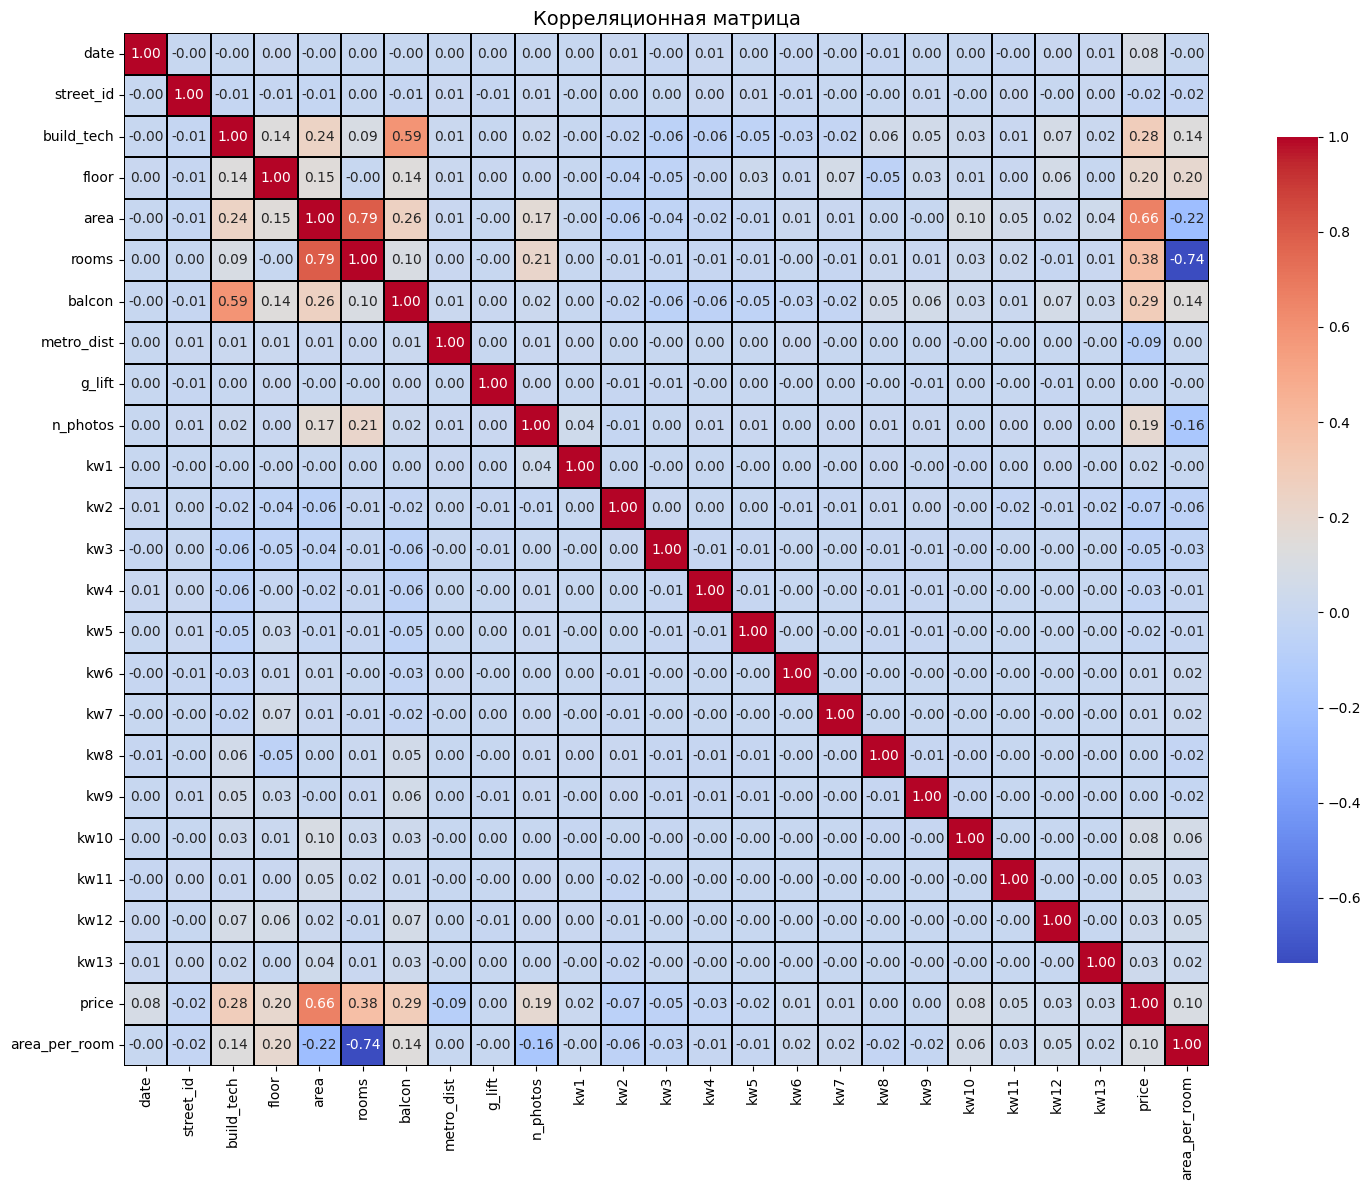

In [134]:
corr = train.corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={"shrink": 0.8}, linewidths=0.3, linecolor='black')

plt.title("Корреляционная матрица", fontsize=14)
plt.tight_layout()
plt.show()


In [139]:
train["build_tech_and_balcon"] = train["build_tech"]*train["balcon"]
test["build_tech_and_balcon"] = test["build_tech"]*test["balcon"]


In [141]:
train["build_tech_and_balcon_and_area"] = train["build_tech"]*train["balcon"]*train["area"]
test["build_tech_and_balcon_and_area"] = test["build_tech"]*test["balcon"]*test["area"]

In [143]:
train["floor_per_room"] = train["floor"]/train["rooms"]
test["floor_per_room"] = test["floor"]/test["rooms"]

In [145]:
train["area_per_balcony"] = np.where(train["balcon"] != 0, train["area"] / train["balcon"], -1)
test["area_per_balcony"] = np.where(test["balcon"] != 0, test["area"] / test["balcon"], -1)

In [162]:
train["area_squared"] = train["area"]**2
test["area_squared"] = test["area"]**2


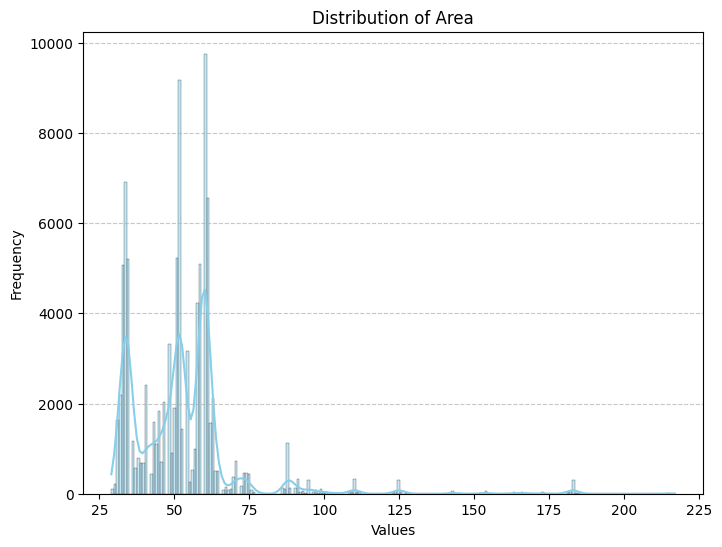

In [164]:
plt.figure(figsize=(8, 6))
sns.histplot(train["area"], color='skyblue', kde=True)
plt.title('Distribution of Area')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [166]:
train['area_bins'] = pd.cut(train['area'], bins=[0, 30, 50, 60, 85, np.inf], labels=['S', 'M', 'L', 'XL', 'XXL'])
test['area_bins'] = pd.cut(test['area'], bins=[0, 30, 50, 60, 85, np.inf], labels=['S', 'M', 'L', 'XL', 'XXL'])

In [168]:
train["k_sum_squared"] = (train["kw1"] + train["kw2"] + train["kw3"] + train["kw4"] + train["kw5"] + train["kw6"] + train["kw7"] 
+ train["kw8"] + train["kw9"] + train["kw10"] + train["kw11"] + train["kw12"] + train["kw13"])**2 

test["k_sum_squared"] = (test["kw1"] + test["kw2"] + test["kw3"] + test["kw4"] + test["kw5"] + test["kw6"] + test["kw7"] 
+ test["kw8"] + test["kw9"] + test["kw10"] + test["kw11"] + test["kw12"] + test["kw13"])**2 

In [172]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   date                            100000 non-null  int32   
 1   street_id                       100000 non-null  int64   
 2   build_tech                      100000 non-null  float64 
 3   floor                           100000 non-null  int64   
 4   area                            100000 non-null  int64   
 5   rooms                           100000 non-null  int64   
 6   balcon                          100000 non-null  int64   
 7   metro_dist                      100000 non-null  float64 
 8   g_lift                          100000 non-null  float64 
 9   n_photos                        100000 non-null  int64   
 10  kw1                             100000 non-null  int64   
 11  kw2                             100000 non-null  int64   
 12  kw3     

In [174]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 100000 to 199999
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   date                            100000 non-null  int32   
 1   street_id                       100000 non-null  int64   
 2   build_tech                      100000 non-null  float64 
 3   floor                           100000 non-null  int64   
 4   area                            100000 non-null  int64   
 5   rooms                           100000 non-null  int64   
 6   balcon                          100000 non-null  int64   
 7   metro_dist                      100000 non-null  float64 
 8   g_lift                          100000 non-null  float64 
 9   n_photos                        100000 non-null  int64   
 10  kw1                             100000 non-null  int64   
 11  kw2                             100000 non-null  int64   
 12  kw

In [189]:
train

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw13,price,area_per_room,build_tech_and_balcon,build_tech_and_balcon_and_area,floor_per_room,area_per_balcony,area_squared,area_bins,k_sum_squared
id,,,,,,,,,,,,,,,,,,,,,
0,1,560,0.0,2,59,3,0,30.0,1.0,5,...,0,4510000,19.666667,0.0,0.0,0.666667,-1.0,3481,L,1
1,1,667,0.0,10,50,2,1,25.0,1.0,1,...,0,13231000,25.000000,0.0,0.0,5.000000,50.0,2500,M,1
2,1,90,0.0,1,48,2,0,25.0,0.0,1,...,0,2008000,24.000000,0.0,0.0,0.500000,-1.0,2304,M,1
3,1,94,1.0,3,62,3,1,30.0,1.0,3,...,0,12680000,20.666667,1.0,62.0,1.000000,62.0,3844,XL,1
4,1,232,0.0,3,60,3,0,25.0,1.0,3,...,0,3335000,20.000000,0.0,0.0,1.000000,-1.0,3600,L,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,15,401,0.0,5,30,1,0,30.0,1.0,1,...,0,1697000,30.000000,0.0,0.0,5.000000,-1.0,900,S,0
99996,15,59,0.0,4,34,1,0,30.0,1.0,1,...,0,3620000,34.000000,0.0,0.0,4.000000,-1.0,1156,M,1
99997,15,253,0.0,3,52,2,0,5.0,1.0,4,...,0,6712000,26.000000,0.0,0.0,1.500000,-1.0,2704,L,1


## Обучение CatBoost

In [192]:
y = train['price']
y

id
0         4510000
1        13231000
2         2008000
3        12680000
4         3335000
           ...   
99995     1697000
99996     3620000
99997     6712000
99998    20835000
99999     2909000
Name: price, Length: 100000, dtype: int64

In [194]:
X = train.drop(['price'], axis=1)
X

,date,street_id,build_tech,floor,area,rooms,balcon,metro_dist,g_lift,n_photos,...,kw12,kw13,area_per_room,build_tech_and_balcon,build_tech_and_balcon_and_area,floor_per_room,area_per_balcony,area_squared,area_bins,k_sum_squared
id,,,,,,,,,,,,,,,,,,,,,
0,1,560,0.0,2,59,3,0,30.0,1.0,5,...,0,0,19.666667,0.0,0.0,0.666667,-1.0,3481,L,1
1,1,667,0.0,10,50,2,1,25.0,1.0,1,...,0,0,25.000000,0.0,0.0,5.000000,50.0,2500,M,1
2,1,90,0.0,1,48,2,0,25.0,0.0,1,...,0,0,24.000000,0.0,0.0,0.500000,-1.0,2304,M,1
3,1,94,1.0,3,62,3,1,30.0,1.0,3,...,0,0,20.666667,1.0,62.0,1.000000,62.0,3844,XL,1
4,1,232,0.0,3,60,3,0,25.0,1.0,3,...,0,0,20.000000,0.0,0.0,1.000000,-1.0,3600,L,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,15,401,0.0,5,30,1,0,30.0,1.0,1,...,0,0,30.000000,0.0,0.0,5.000000,-1.0,900,S,0
99996,15,59,0.0,4,34,1,0,30.0,1.0,1,...,0,0,34.000000,0.0,0.0,4.000000,-1.0,1156,M,1
99997,15,253,0.0,3,52,2,0,5.0,1.0,4,...,0,0,26.000000,0.0,0.0,1.500000,-1.0,2704,L,1


In [196]:
categorial_features = ('street_id', 'balcon', 'rooms', "area_bins")

In [198]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=13)

In [202]:
boosting_model = CatBoostRegressor(iterations=1000,
                           loss_function='MAE',  
                           eval_metric='MAE', 
                           objective='MAE',
                           logging_level='Silent',
                           cat_features=categorial_features,
                           early_stopping_rounds=1000,
                           random_seed=13)
grid = {
    'learning_rate': [0.06, 0.10, 0.14],
    'depth': [5,6,7]
}
grid_search_result = boosting_model.grid_search(grid, 
                                               X=X_train, 
                                               y=y_train,
                                               cv=5,
                                               train_size=0.8,
                                               plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	loss: 728398.9001189	best: 728398.9001189 (0)	total: 33.2s	remaining: 4m 25s
1:	loss: 694420.3476206	best: 694420.3476206 (1)	total: 1m 5s	remaining: 3m 49s
2:	loss: 684385.7707312	best: 684385.7707312 (2)	total: 1m 38s	remaining: 3m 16s
3:	loss: 700073.2196342	best: 684385.7707312 (2)	total: 2m 16s	remaining: 2m 51s
4:	loss: 674575.1060148	best: 674575.1060148 (4)	total: 2m 55s	remaining: 2m 20s
5:	loss: 667113.0093055	best: 667113.0093055 (5)	total: 3m 34s	remaining: 1m 47s
6:	loss: 678523.0225411	best: 667113.0093055 (5)	total: 4m 19s	remaining: 1m 14s
7:	loss: 662257.8865065	best: 662257.8865065 (7)	total: 5m 5s	remaining: 38.1s
8:	loss: 663710.7328902	best: 662257.8865065 (7)	total: 5m 50s	remaining: 0us
Estimating final quality...


In [256]:
print("Best model parameters: " + str(grid_search_result['params'])) 
print("Model test score: " + str(round(mean_absolute_error(boosting_model.predict(X_test), y_test))))

Best model parameters: {'depth': 7, 'learning_rate': 0.1}
Model test score: 633311


## Тестирование лучшей модели

In [226]:
best_model_1 = CatBoostRegressor(iterations=5000,
                  loss_function='MAE',  
                  eval_metric='MAE',
                  logging_level='Silent',
                  depth=7,
                  learning_rate=0.05,
                  cat_features=categorial_features,
                  early_stopping_rounds=100,
                  random_seed=13)
best_model_1.fit(X_train, y_train)

In [254]:
y_pred_1 = best_model_1.predict(X_test)
print("Model test score: " + str(round(mean_absolute_error(y_pred_1, y_test))))

Model test score: 606883


## Финальная модель

In [266]:
best_model = CatBoostRegressor(iterations=5000,
                  loss_function='MAE',  
                  eval_metric='MAE',
                  logging_level='Silent',
                  depth=6,
                  learning_rate=0.1,
                  cat_features=categorial_features,
                  early_stopping_rounds=100,
                  random_seed=13)
best_model.fit(X, y)

In [268]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 100000 to 199999
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype   
---  ------                          --------------   -----   
 0   date                            100000 non-null  int32   
 1   street_id                       100000 non-null  int64   
 2   build_tech                      100000 non-null  float64 
 3   floor                           100000 non-null  int64   
 4   area                            100000 non-null  int64   
 5   rooms                           100000 non-null  int64   
 6   balcon                          100000 non-null  int64   
 7   metro_dist                      100000 non-null  float64 
 8   g_lift                          100000 non-null  float64 
 9   n_photos                        100000 non-null  int64   
 10  kw1                             100000 non-null  int64   
 11  kw2                             100000 non-null  int64   
 12  kw

In [270]:
y_pred = best_model.predict(test)

In [272]:
submission = pd.DataFrame({'id':test.index, 'price':y_pred})
submission.to_csv('submission_best.csv', index=False)
submission.head()

,id,price
0,100000,8.572441e+06
1,100001,4.293243e+06
2,100002,3.806870e+06
3,100003,2.931984e+06
4,100004,6.933369e+06
